# 01 — Exploratory Data Analysis
**India GDP forecasting project.** Input: `data/processed/composite_master_quarterly.csv`
(built by `src/build_composite.py`). This notebook explores the panel and produces the
**feature-selection (keep/drop) decision** plus the figures used downstream.

Sections:
1. Setup & coverage / missingness map
2. Time-series small multiples
3. Correlation heatmap + VIF → collinearity pruning
4. Lead–lag cross-correlation with GDP
5. Stationarity (ADF + KPSS)
6. Base-year overlay (2011-12 vs 2022-23) — the headline story

Every figure is written to `outputs/figures/`.

## 0 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titlesize": 11, "axes.titleweight": "bold", "figure.facecolor": "white",
})
BLUE, RED, GREY = "#2c7fb8", "#d1495b", "#9aa0a6"

# >>> YOUR PROJECT FOLDER — change this one line only if you move the project <<<
PROJECT = Path("C:/Users/asus/Projects/GDP")

CSV  = PROJECT / "data" / "processed" / "composite_master_quarterly.csv"
FIGS = PROJECT / "outputs" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
print("project:", PROJECT)
print("reading:", CSV.name)

project: C:/Users/asus/Projects/GDP
reading: composite_master_quarterly.csv


In [2]:
def fq_to_date(label):
    """'2011-12 Q1' -> quarter-END Timestamp (Apr-Jun FY -> 30 Jun)."""
    fy = int(label[:4]); q = int(label[-1])
    end_month = {1: 6, 2: 9, 3: 12, 4: 3}[q]
    year = fy if q <= 3 else fy + 1
    return pd.Timestamp(year=year, month=end_month, day=1) + pd.offsets.MonthEnd(0)

df = pd.read_csv(CSV)
df["date"] = df["FY_Quarter"].map(fq_to_date)
df = df.sort_values("date").set_index("date")

TARGET = "GDP_growth_old"
ID_COLS = ["FY_Quarter", "base_year_target"]
numeric = [c for c in df.columns if c not in ID_COLS and pd.api.types.is_numeric_dtype(df[c])]
print(f"shape {df.shape} | {len(numeric)} numeric columns")
df.head(3)

shape (62, 44) | 41 numeric columns


,FY_Quarter,GDP_growth_old,GFCE,PFCE,GFCF,Exports,Imports,NetExports,FiscalDeficit_pct_GDP,Repo_QtrAvg,...,Q1,Q2,Q3,Q4,COVID,BaseRevision_gap,GDP_growth,GDP_growth_source,GDP_growth_lag1,GDP_growth_lag4
date,,,,,,,,,,,,,,,,,,,,,
2011-06-30,2011-12 Q1,NaN,204165.1,1236604.4,696954.8,506866.9,643806.3,-136939.4,5.7,7.114247,...,1,0,0,0,0,NaN,NaN,—,NaN,NaN
2011-09-30,2011-12 Q2,NaN,257146.7,1127292.9,727748.9,507189.2,640633.6,-133444.4,5.7,7.907258,...,0,1,0,0,0,NaN,NaN,—,NaN,NaN
2011-12-31,2011-12 Q3,NaN,220375.1,1264939.5,752161.7,553499.2,713920.6,-160421.4,5.7,8.435484,...,0,0,1,0,0,NaN,NaN,—,NaN,NaN


## 1 · Coverage & missingness
The head/tail gaps are **structural, not errors**: YoY features need 4 prior quarters,
and 2025-26 Q3/Q4 are still in the future for the old-base target. The new-base columns
only start in 2022-23 because that series didn't exist before the rebasing.

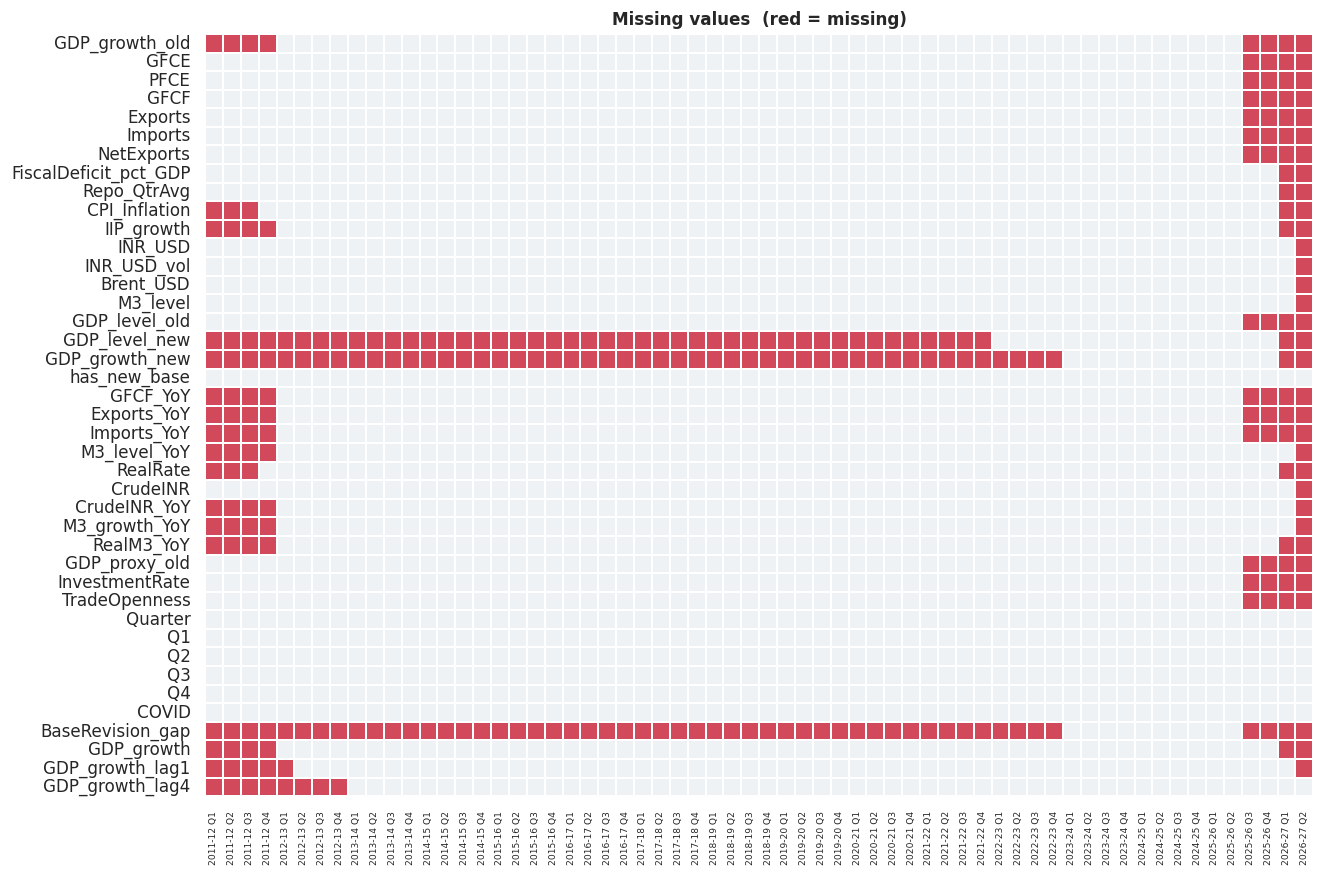

BaseRevision_gap    52
GDP_growth_new      50
GDP_level_new       46
GFCF_YoY             8
Imports_YoY          8
Exports_YoY          8
GDP_growth_lag4      8
GDP_growth_old       8
IIP_growth           6
GDP_growth_lag1      6


In [3]:
miss = df[numeric].isna()
fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(miss.T, cmap=ListedColormap(["#eef2f5", RED]), cbar=False,
            linewidths=0.3, linecolor="white", ax=ax)
ax.set_xticks(np.arange(len(df)) + 0.5)
ax.set_xticklabels(df["FY_Quarter"], rotation=90, fontsize=6)
ax.set_title("Missing values  (red = missing)")
ax.set_xlabel(""); ax.set_ylabel("")
fig.savefig(FIGS / "01_missingness.png"); plt.show()

print(df[numeric].isna().sum().sort_values(ascending=False).head(10).to_string())

## 2 · Time-series small multiples
One mini-panel per series. The COVID shock (2020-21) is shaded so it's easy to see how
each indicator reacted. Pure dummies/flags are excluded.

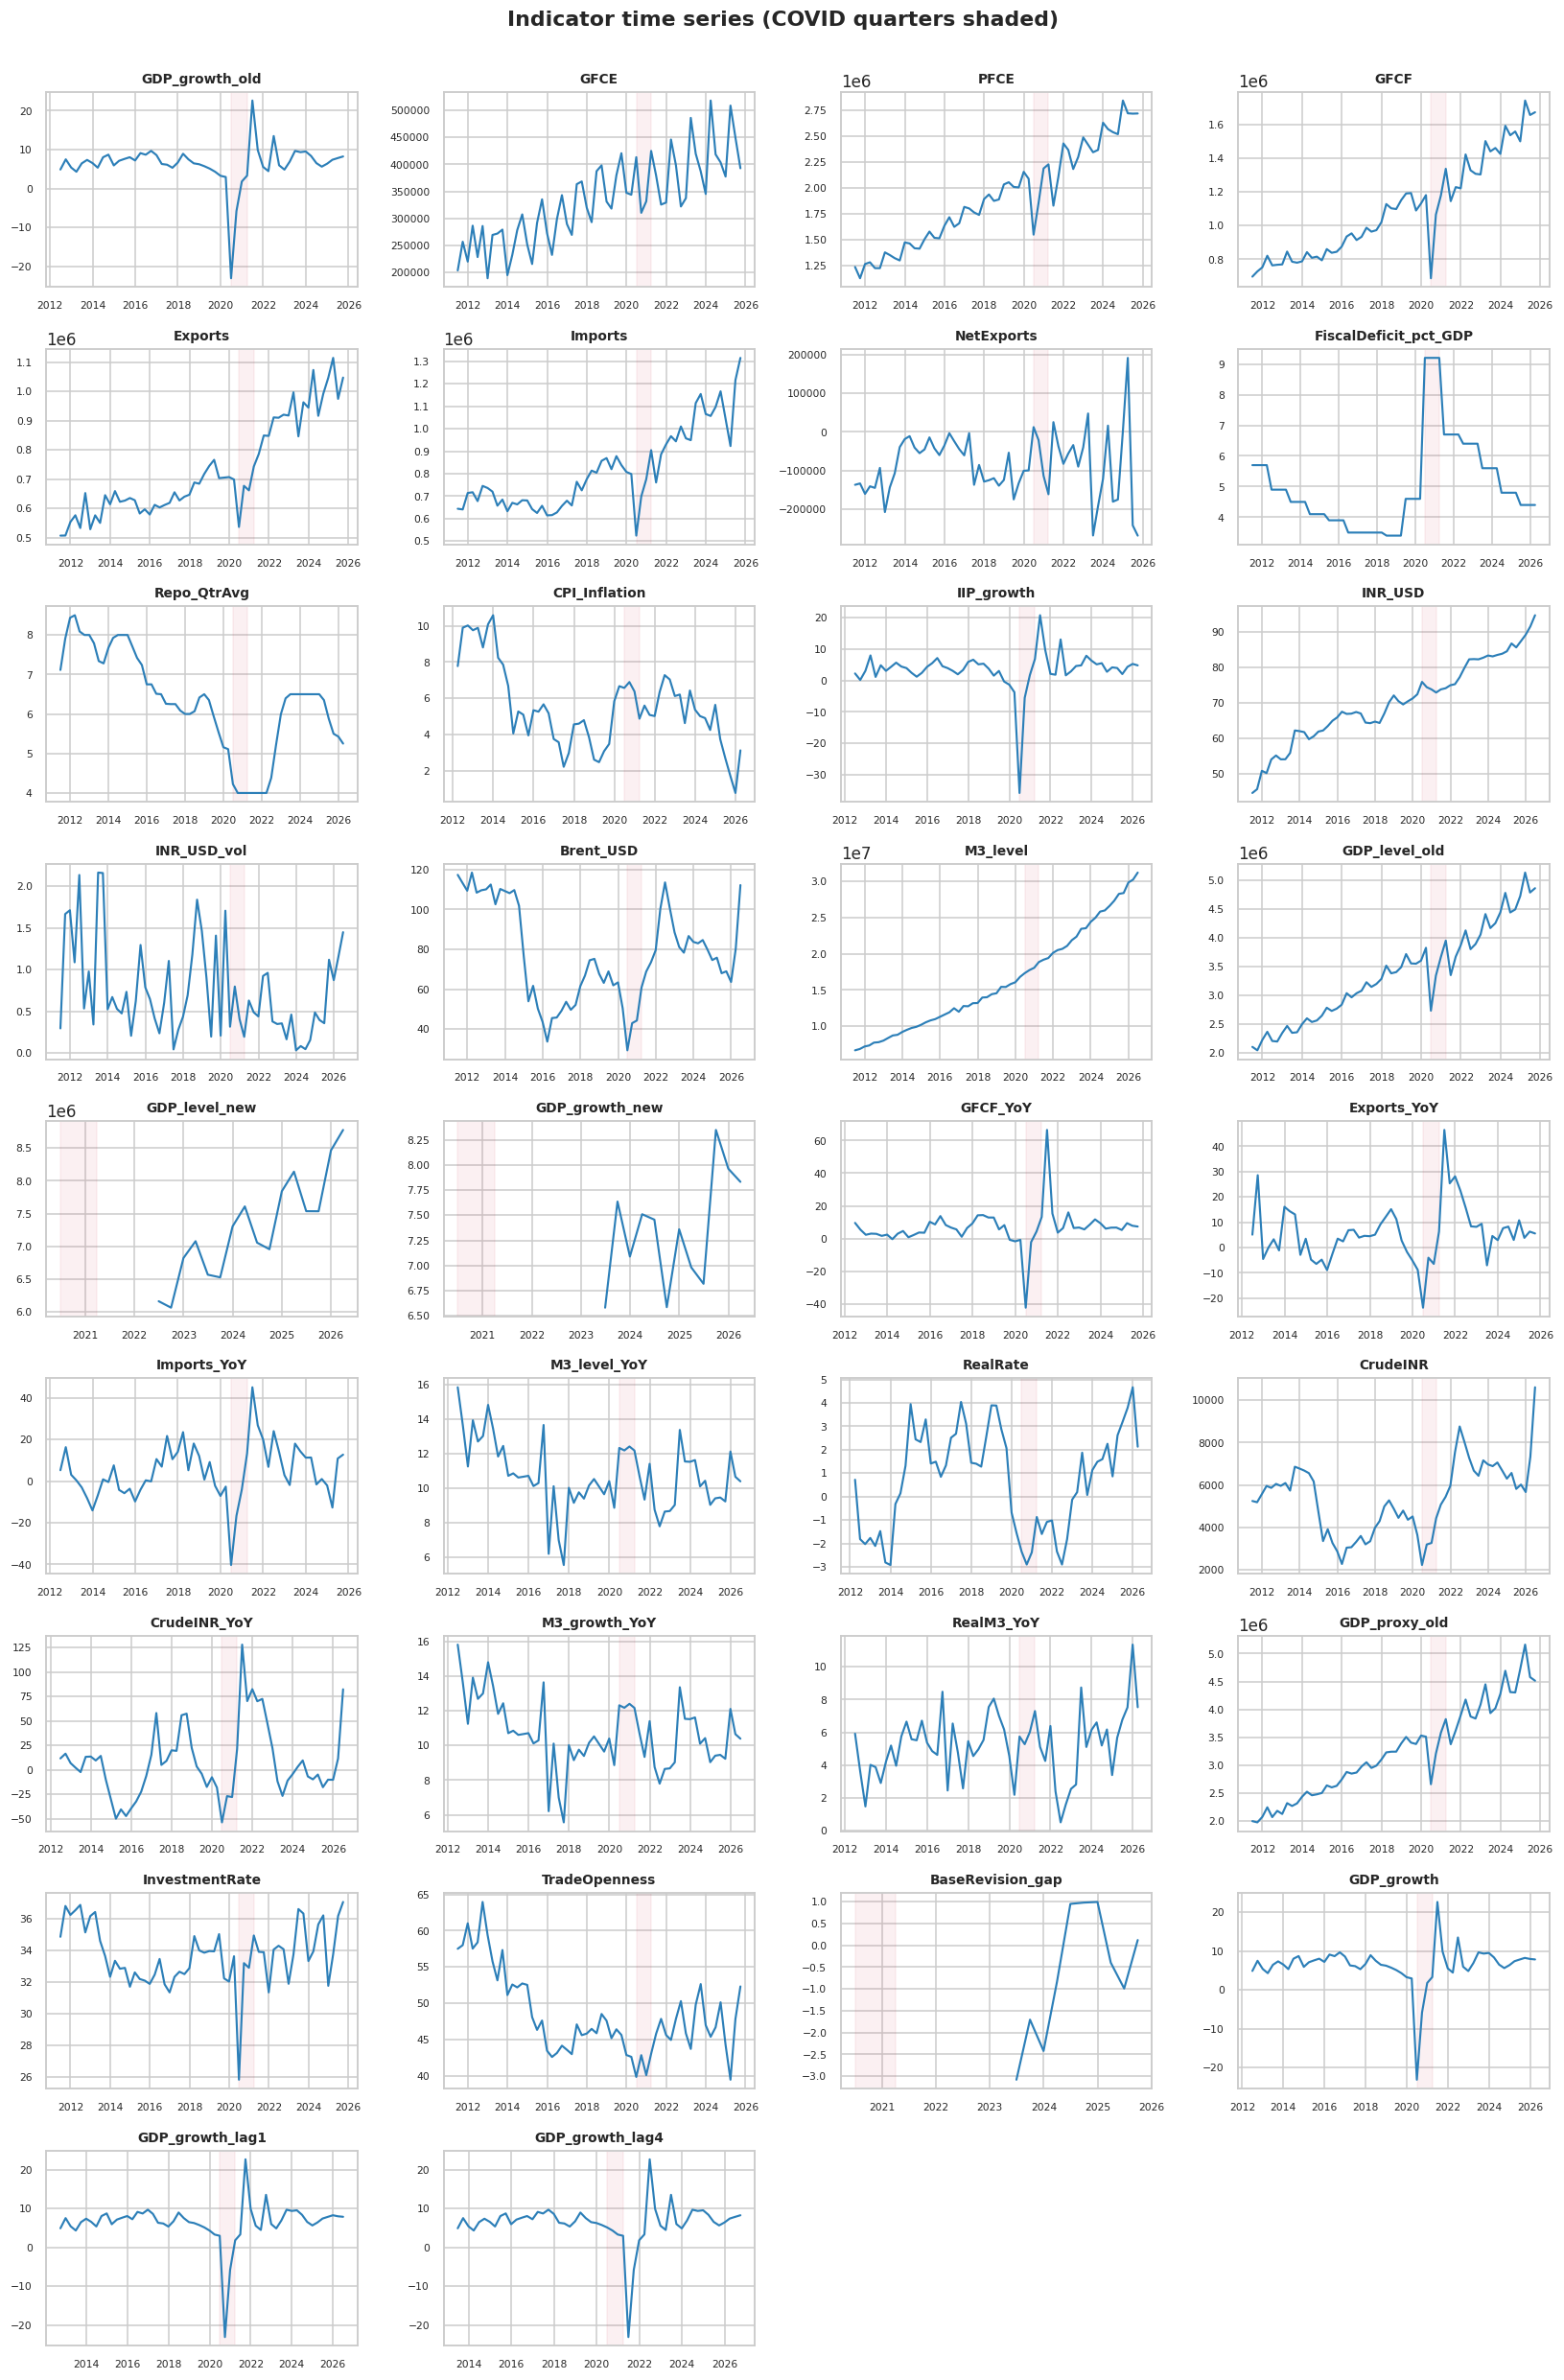

In [4]:
skip = {"Q1", "Q2", "Q3", "Q4", "COVID", "has_new_base", "Quarter"}
plot_cols = [c for c in numeric if c not in skip]

covid_lo, covid_hi = fq_to_date("2020-21 Q1"), fq_to_date("2020-21 Q4")
ncol = 4; nrow = int(np.ceil(len(plot_cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5 * nrow))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.plot(df.index, df[col], color=BLUE, lw=1.4)
    ax.axvspan(covid_lo, covid_hi, color=RED, alpha=0.08)
    ax.set_title(col, fontsize=9); ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")
fig.suptitle("Indicator time series (COVID quarters shaded)", y=1.002, fontweight="bold")
fig.tight_layout(); fig.savefig(FIGS / "02_small_multiples.png"); plt.show()

## 3 · Correlation & multicollinearity → the drop decision
This is where feature **selection** happens. We deliberately include redundant pairs
(level *and* its YoY twin, `NetExports`, the `M3_growth_YoY` alias) so the collinearity
is visible. The heatmap shows it; **VIF** quantifies it; the recommendation table at the
end is the keep/drop call that feeds notebook 02.

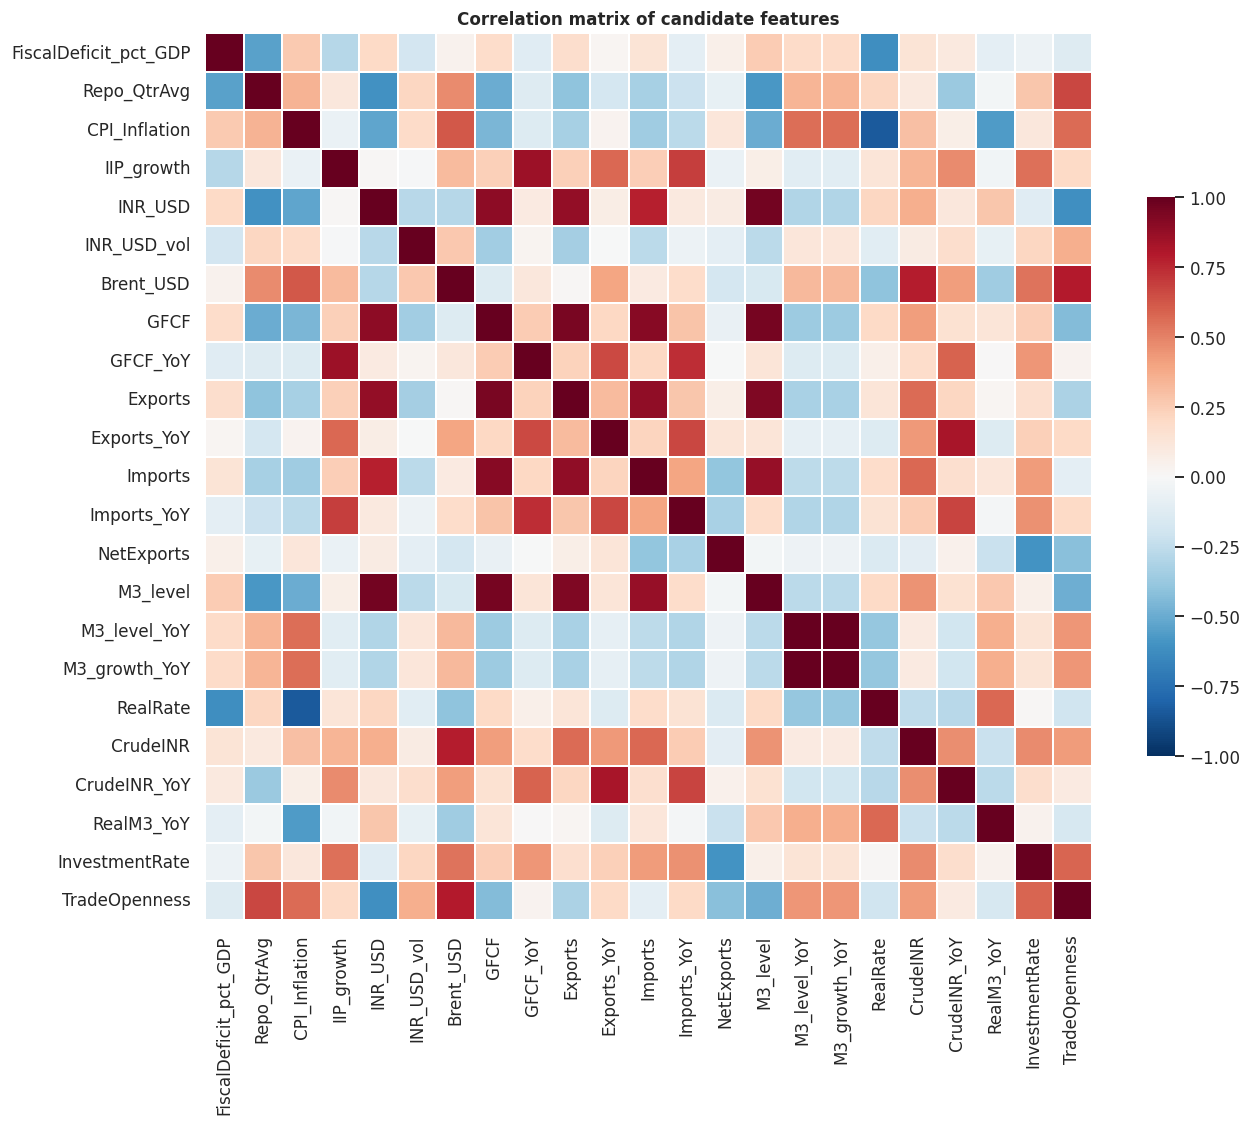

In [5]:
cand = [
    "FiscalDeficit_pct_GDP", "Repo_QtrAvg", "CPI_Inflation", "IIP_growth",
    "INR_USD", "INR_USD_vol", "Brent_USD",
    "GFCF", "GFCF_YoY", "Exports", "Exports_YoY", "Imports", "Imports_YoY", "NetExports",
    "M3_level", "M3_level_YoY", "M3_growth_YoY",
    "RealRate", "CrudeINR", "CrudeINR_YoY", "RealM3_YoY",
    "InvestmentRate", "TradeOpenness",
    "GDP_growth_old_lag1", "GDP_growth_old_lag4",
]
cand = [c for c in cand if c in df.columns]
corr = df[cand].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Correlation matrix of candidate features"); plt.show()
fig.savefig(FIGS / "03a_corr_heatmap.png")

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF on complete cases; drop one seasonal dummy elsewhere (not in cand) to avoid the trap.
X = df[cand].dropna()
Xc = add_constant(X)
vif = pd.Series(
    [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
    index=Xc.columns,
).drop("const").sort_values(ascending=False)
print("VIF (inf = perfectly collinear, e.g. an exact alias / linear combo):")
print(vif.round(1).to_string())

VIF (inf = perfectly collinear, e.g. an exact alias / linear combo):
Repo_QtrAvg                       inf
CPI_Inflation                     inf
RealM3_YoY                        inf
M3_level_YoY                      inf
M3_growth_YoY                     inf
RealRate                          inf
Imports                  1.937032e+13
Exports                  1.547629e+13
NetExports               4.079347e+12
GFCF                     3.901000e+02
Brent_USD                3.843000e+02
CrudeINR                 3.612000e+02
INR_USD                  1.667000e+02
M3_level                 8.630000e+01
TradeOpenness            7.110000e+01
InvestmentRate           3.020000e+01
GFCF_YoY                 1.260000e+01
IIP_growth               1.030000e+01
CrudeINR_YoY             1.030000e+01
Imports_YoY              9.200000e+00
Exports_YoY              7.500000e+00
FiscalDeficit_pct_GDP    6.900000e+00
INR_USD_vol              2.100000e+00


In [7]:
# Programmatic keep/drop recommendation.
# Rule: flag a feature if it has |corr|>0.95 with another, OR VIF>10. Keep the
# more interpretable / stationary twin (prefer YoY over level; drop exact aliases).
hi_pairs = []
cc = corr.abs()
for i in range(len(cand)):
    for j in range(i + 1, len(cand)):
        r = cc.iloc[i, j]
        if r > 0.95:
            hi_pairs.append((cand[i], cand[j], round(corr.iloc[i, j], 3)))

drop = {
    "NetExports":     "exact linear combo: Exports - Imports (VIF inf)",
    "M3_growth_YoY":  "exact alias of M3_level_YoY (VIF inf)",
    "GFCF":           "level; keep GFCF_YoY (stationary twin)",
    "Exports":        "level; keep Exports_YoY",
    "Imports":        "level; keep Imports_YoY",
    "M3_level":       "level; keep M3_level_YoY",
    "CrudeINR":       "level; keep CrudeINR_YoY (Brent_USD already in)",
    # composite == exact linear combo of its parents -> can't keep all three.
    # Default: keep the raw, interpretable parents; drop the composite.
    # (Alternative design: keep RealRate, drop Repo_QtrAvg + CPI_Inflation.)
    "RealRate":       "= Repo_QtrAvg - CPI_Inflation; both parents kept (VIF inf)",
    "RealM3_YoY":     "= M3_level_YoY - CPI_Inflation; both parents kept (VIF inf)",
}
rec = pd.DataFrame({"feature": list(drop), "reason": list(drop.values())})
print("High-correlation pairs (|r| > 0.95):")
for a, b, r in hi_pairs:
    print(f"  {a:22} ~ {b:22} r={r}")
print()
print("RECOMMENDED DROPS (collinearity / redundancy):")
print(rec.to_string(index=False))

kept = [c for c in cand if c not in drop]
print(f"\nFeatures kept after pruning ({len(kept)}): {kept}")

High-correlation pairs (|r| > 0.95):
  INR_USD                ~ M3_level               r=0.965
  GFCF                   ~ Exports                r=0.951
  GFCF                   ~ M3_level               r=0.955
  M3_level_YoY           ~ M3_growth_YoY          r=1.0

RECOMMENDED DROPS (collinearity / redundancy):
      feature                                                      reason
   NetExports             exact linear combo: Exports - Imports (VIF inf)
M3_growth_YoY                       exact alias of M3_level_YoY (VIF inf)
         GFCF                      level; keep GFCF_YoY (stationary twin)
      Exports                                     level; keep Exports_YoY
      Imports                                     level; keep Imports_YoY
     M3_level                                    level; keep M3_level_YoY
     CrudeINR             level; keep CrudeINR_YoY (Brent_USD already in)
     RealRate  = Repo_QtrAvg - CPI_Inflation; both parents kept (VIF inf)
   RealM3_YoY = M3_

In [8]:
# Prove it worked: VIF on the PRUNED set. The inf / 1e13 cases are gone.
Xk = add_constant(df[kept].dropna())
vif_after = pd.Series(
    [variance_inflation_factor(Xk.values, i) for i in range(Xk.shape[1])],
    index=Xk.columns,
).drop("const").sort_values(ascending=False)
print("VIF after pruning:")
print(vif_after.round(2).to_string())
print("\nNote: the inf / 1e13 cases are gone; the worst residual VIF is now ~15")
print("(GFCF_YoY, IIP_growth, CrudeINR_YoY). That moderate macro collinearity is expected")
print("and is handled by regularization (Ridge/Lasso) in notebook 02, not by dropping more.")

VIF after pruning:
Repo_QtrAvg              10.82
Brent_USD                 9.67
CrudeINR_YoY              9.30
TradeOpenness             9.01
GFCF_YoY                  8.62
IIP_growth                7.73
Imports_YoY               7.40
FiscalDeficit_pct_GDP     5.61
CPI_Inflation             5.40
Exports_YoY               4.82
INR_USD                   3.36
InvestmentRate            3.27
M3_level_YoY              2.37
INR_USD_vol               1.67

Note: the inf / 1e13 cases are gone; the worst residual VIF is now ~15
(GFCF_YoY, IIP_growth, CrudeINR_YoY). That moderate macro collinearity is expected
and is handled by regularization (Ridge/Lasso) in notebook 02, not by dropping more.


## 4 · Lead–lag: which indicators move *before* GDP?
Cross-correlation of each indicator with the GDP-growth target at lags −4…+4 quarters.
A peak at **positive lag** means the indicator *leads* GDP (useful as a predictor and a
justification for the lag features). Peak bar is highlighted.

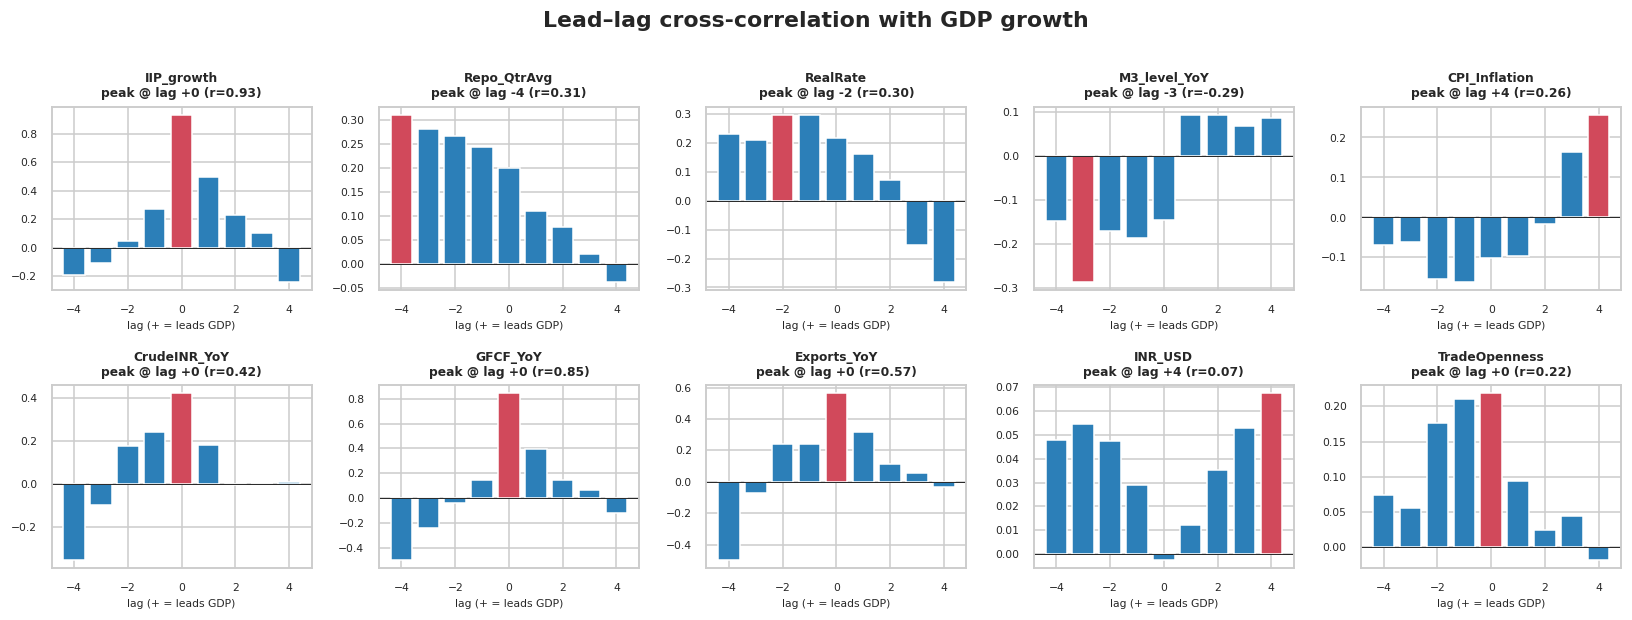

In [9]:
def ccf(target, x, max_lag=4):
    # corr(target_t, x_{t-k}); k>0 => x leads target by k quarters
    return pd.Series({k: target.corr(x.shift(k)) for k in range(-max_lag, max_lag + 1)})

leads = ["IIP_growth", "Repo_QtrAvg", "RealRate", "M3_level_YoY", "CPI_Inflation",
         "CrudeINR_YoY", "GFCF_YoY", "Exports_YoY", "INR_USD", "TradeOpenness"]
leads = [c for c in leads if c in df.columns]
tgt = df[TARGET]

ncol = 5; nrow = int(np.ceil(len(leads) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.8 * nrow))
for ax, col in zip(axes.ravel(), leads):
    s = ccf(tgt, df[col])
    peak = s.abs().idxmax()
    colors = [RED if k == peak else BLUE for k in s.index]
    ax.bar(s.index, s.values, color=colors)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{col}\npeak @ lag {peak:+d} (r={s[peak]:.2f})", fontsize=8)
    ax.set_xlabel("lag (+ = leads GDP)", fontsize=7); ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(leads):]:
    ax.axis("off")
fig.suptitle("Lead–lag cross-correlation with GDP growth", y=1.003, fontweight="bold")
fig.tight_layout(); fig.savefig(FIGS / "04_lead_lag.png"); plt.show()

## 5 · Stationarity (ADF + KPSS)
Two complementary tests. **ADF**: p<0.05 ⇒ stationary (rejects unit root).
**KPSS**: p<0.05 ⇒ *non*-stationary (rejects stationarity). When they agree you have a
clear verdict. This is why we model growth/YoY forms, not raw levels — and it sets the
differencing for ARIMA/SARIMAX in notebook 02.

In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

def verdict(s):
    s = s.dropna()
    if len(s) < 12:
        return (np.nan, np.nan, "too short")
    adf_p = adfuller(s, autolag="AIC")[1]
    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = np.nan
    adf_stat = adf_p < 0.05            # True => stationary
    kpss_stat = (kpss_p > 0.05)        # True => stationary
    if adf_stat and kpss_stat:   v = "stationary"
    elif not adf_stat and not kpss_stat: v = "non-stationary"
    else: v = "borderline"
    return (round(adf_p, 3), round(kpss_p, 3), v)

check = [TARGET, "GDP_level_old", "GFCF", "GFCF_YoY", "Exports", "Exports_YoY",
         "M3_level", "M3_level_YoY", "CPI_Inflation", "Repo_QtrAvg", "RealRate",
         "IIP_growth", "INR_USD", "Brent_USD", "TradeOpenness"]
check = [c for c in check if c in df.columns]
rows = [(c, *verdict(df[c])) for c in check]
stat = pd.DataFrame(rows, columns=["series", "ADF_p", "KPSS_p", "verdict"])
stat

/tmp/ipykernel_547/4018178923.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
/tmp/ipykernel_547/4018178923.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
/tmp/ipykernel_547/4018178923.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
/tmp/ipykernel_547/4018178923.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression="c

,series,ADF_p,KPSS_p,verdict
0,GDP_growth_old,0.000,0.100,stationary
1,GDP_level_old,0.992,0.010,non-stationary
2,GFCF,0.995,0.010,non-stationary
3,GFCF_YoY,0.000,0.100,stationary
4,Exports,0.987,0.010,non-stationary
5,Exports_YoY,0.000,0.100,stationary
6,M3_level,1.000,0.010,non-stationary
7,M3_level_YoY,0.113,0.090,borderline
8,CPI_Inflation,0.345,0.049,non-stationary
9,Repo_QtrAvg,0.215,0.010,non-stationary


## 6 · Base-year overlay — the headline story
On **27 Feb 2026** MoSPI rebased GDP from base 2011-12 to 2022-23. We carry both series.
Below: old vs new quarterly growth, with the revision gap (`new − old`) shaded and barred.
This panel motivates the base-sensitivity analysis (does the answer to *what drives GDP*
change with the base year?) done in notebook 02/03.

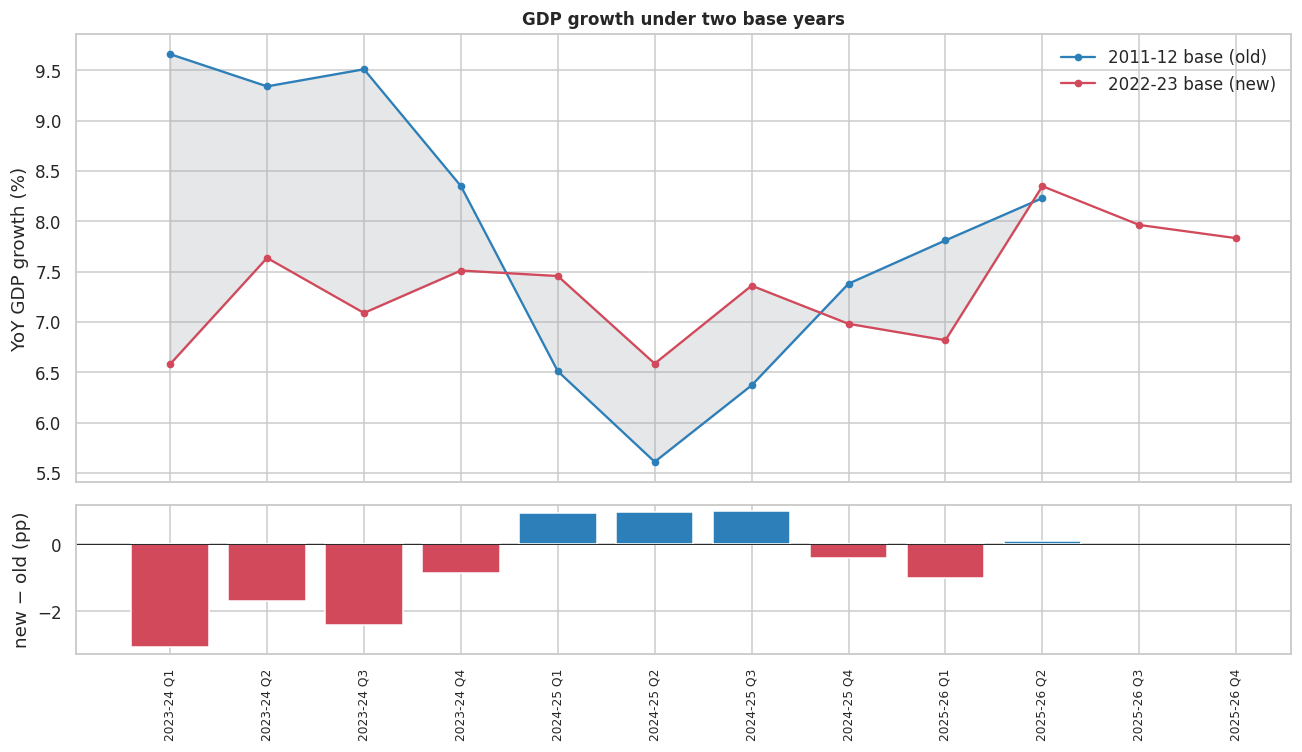

Mean absolute revision: 1.25 pp over 12 overlapping quarters


In [11]:
ov = df.loc[df["GDP_growth_new"].notna(), ["FY_Quarter", "GDP_growth_old",
                                            "GDP_growth_new", "BaseRevision_gap"]]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                             gridspec_kw={"height_ratios": [3, 1]})
x = np.arange(len(ov))
a1.plot(x, ov["GDP_growth_old"], "-o", color=BLUE, label="2011-12 base (old)", ms=4)
a1.plot(x, ov["GDP_growth_new"], "-o", color=RED,  label="2022-23 base (new)", ms=4)
a1.fill_between(x, ov["GDP_growth_old"], ov["GDP_growth_new"], color=GREY, alpha=0.25)
a1.set_ylabel("YoY GDP growth (%)"); a1.legend(frameon=False)
a1.set_title("GDP growth under two base years")

colors = [RED if g < 0 else BLUE for g in ov["BaseRevision_gap"]]
a2.bar(x, ov["BaseRevision_gap"], color=colors)
a2.axhline(0, color="k", lw=0.6)
a2.set_ylabel("new − old (pp)")
a2.set_xticks(x); a2.set_xticklabels(ov["FY_Quarter"], rotation=90, fontsize=8)
fig.tight_layout(); fig.savefig(FIGS / "06_base_year_overlay.png"); plt.show()

print("Mean absolute revision: "
      f"{ov['BaseRevision_gap'].abs().mean():.2f} pp over {len(ov)} overlapping quarters")

## 7 · Base-year revision: impact summary
A compact summary of what the 27 Feb 2026 rebasing (2011-12 -> 2022-23) actually did. The
headline figures below are from MoSPI / PIB press notes; the quarterly revision gap is computed
from our own spliced panel.

In [12]:
# Official before/after headline figures (MoSPI / PIB press notes, Feb-Jun 2026).
facts = pd.DataFrame({
    "Old (2011-12 base)": ["7.4%", "~Rs 357 lakh cr", "4.4%", "~180"],
    "New (2022-23 base)": ["7.6%", "~Rs 345 lakh cr  (-3.3%)", "4.5%", "~600"],
}, index=["Real GDP growth, FY2025-26",
          "Nominal GDP, FY2025-26",
          "Fiscal deficit (% of GDP), FY2025-26",
          "Number of deflators used"])
print("OFFICIAL HEADLINE IMPACT (source: MoSPI/PIB):")
print(facts.to_string())

# Data-derived impact from our overlap (new minus old quarterly growth).
gap = ov["BaseRevision_gap"]
print(f"\nFrom our panel ({len(ov)} overlapping quarters):")
print(f"  mean absolute revision : {gap.abs().mean():.2f} pp")
print(f"  largest downward revision: {gap.min():+.2f} pp ({ov.loc[gap.idxmin(),'FY_Quarter']})")
print(f"  largest upward revision  : {gap.max():+.2f} pp ({ov.loc[gap.idxmax(),'FY_Quarter']})")
facts

OFFICIAL HEADLINE IMPACT (source: MoSPI/PIB):
                                     Old (2011-12 base)        New (2022-23 base)
Real GDP growth, FY2025-26                         7.4%                      7.6%
Nominal GDP, FY2025-26                  ~Rs 357 lakh cr  ~Rs 345 lakh cr  (-3.3%)
Fiscal deficit (% of GDP), FY2025-26               4.4%                      4.5%
Number of deflators used                           ~180                      ~600

From our panel (12 overlapping quarters):
  mean absolute revision : 1.25 pp
  largest downward revision: -3.08 pp (2023-24 Q1)
  largest upward revision  : +0.99 pp (2024-25 Q3)


,Old (2011-12 base),New (2022-23 base)
"Real GDP growth, FY2025-26",7.4%,7.6%
"Nominal GDP, FY2025-26",~Rs 357 lakh cr,~Rs 345 lakh cr (-3.3%)
"Fiscal deficit (% of GDP), FY2025-26",4.4%,4.5%
Number of deflators used,~180,~600


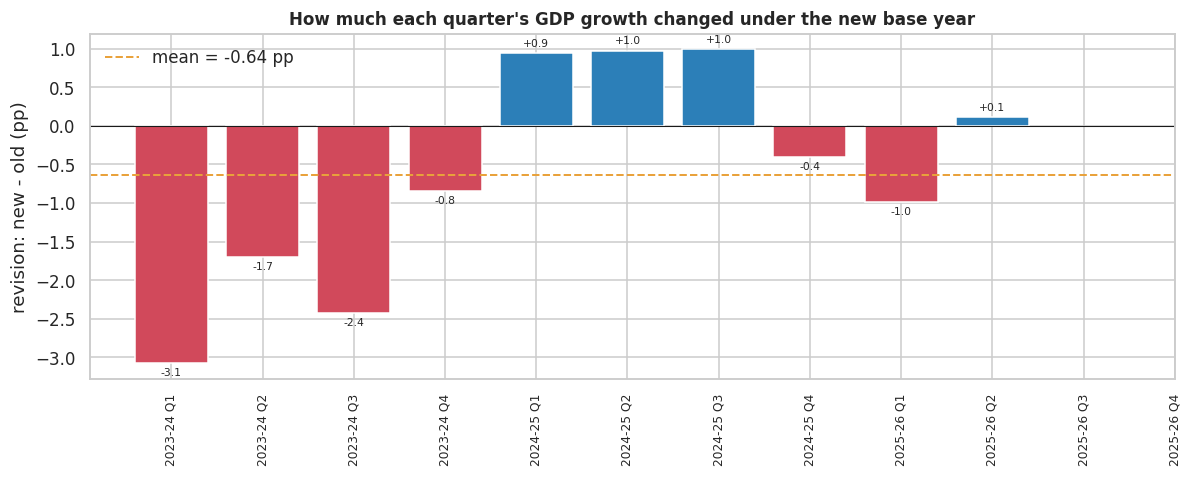

In [13]:
# Quarter-by-quarter revision: how much each quarter's growth moved (new - old).
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [RED if g < 0 else BLUE for g in ov["BaseRevision_gap"]]
ax.bar(range(len(ov)), ov["BaseRevision_gap"], color=colors)
ax.axhline(0, color="k", lw=0.7)
ax.axhline(ov["BaseRevision_gap"].mean(), color="#e9a23b", ls="--", lw=1.3,
           label=f"mean = {ov['BaseRevision_gap'].mean():+.2f} pp")
ax.set_xticks(range(len(ov))); ax.set_xticklabels(ov["FY_Quarter"], rotation=90, fontsize=8)
ax.set_ylabel("revision: new - old (pp)")
ax.set_title("How much each quarter's GDP growth changed under the new base year")
ax.legend(frameon=False)
for i, g in enumerate(ov["BaseRevision_gap"]):
    ax.annotate(f"{g:+.1f}", (i, g), ha="center", fontsize=7,
                va="bottom" if g >= 0 else "top",
                xytext=(0, 3 if g >= 0 else -3), textcoords="offset points")
fig.tight_layout(); fig.savefig(FIGS / "07_base_revision_impact.png"); plt.show()

**Reading the impact.** The rebasing *raised* headline FY25-26 real growth slightly (7.4% ->
7.6%) but *shrank* the nominal economy by about 3.3%, which mechanically lifted the fiscal-deficit
ratio (4.4% -> 4.5%) with no extra borrowing. Quarter by quarter the revision is non-trivial -
averaging about 1.25 pp and switching sign across years - which is why we (i) splice the two series
into one continuous target and (ii) report the driver analysis under both bases (notebook 02).

## EDA takeaways → into notebook 02
- **Missingness** is structural (YoY warm-up + future quarters + new series start). No imputation needed for the head/tail; modelling just starts after the warm-up.
- **Collinearity** is real and was pruned: drop the level twins (`GFCF`, `Exports`, `Imports`, `M3_level`, `CrudeINR`), the exact alias (`M3_growth_YoY`), and the linear combo (`NetExports`). Keep the YoY/stationary forms.
- **Lead–lag** confirms several indicators lead GDP — supports the `*_lag` features.
- **Stationarity** confirms levels are non-stationary while growth/YoY forms are (mostly) stationary → model the growth forms; set ARIMA `d` accordingly.
- **Base year** matters: the revision averages a non-trivial gap per quarter, so the forecast and feature-importance must be reported *per base* (the sensitivity study).